# GSE125527_pbmc 初步分析
数据集样本合并，初步过滤

血液组织 免疫细胞 样本，15个样本  
7UC，8HC
- UC27-UC33
- HC31-HC38

# 文件说明
- **文件名**: 6_GSE125527_pbmc.h5ad  
- **存放位置**: 坚果云  `UC/scRNA-seq_data/02_sample_merge/`  
- **生成日期**: 2025-10-23  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/6_GSE125527_pbmc_preprocessing.ipynb  
- **内容说明**: 数据集样本合并，包含初步质控和去除双细胞后的数据集数据，保存为h5ad文件，方便后续合并时读取  

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


In [2]:
!pwd

/home/future/UC_Treg_Project/notebooks/1_preprocessing


## 读取表达矩阵类型数据

In [3]:
import pandas as pd
import os

data_dir = "/mnt/e/UC/scRNA-seq_RAW/6_GSE125527/PBMC"
adatas = []

for file in sorted(os.listdir(data_dir)):
    if not (file.endswith(".tsv") or file.endswith(".csv") or file.endswith(".txt")):
        continue

    path = os.path.join(data_dir, file)
    sample = os.path.splitext(file)[0]

    # 自动识别分隔符
    sep = "\t" if file.endswith((".tsv", ".txt")) else ","
    df = pd.read_csv(path, sep=sep, index_col=0)

    ad = sc.AnnData(df) # 针对这个表达矩阵不转置
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)

    ad.obs['GSM_id'] = sample
    ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names]
    adatas.append(ad)

adata = sc.concat(adatas, merge='same')

filtered out 56 genes that are detected in less than 3 cells
filtered out 42 genes that are detected in less than 3 cells
filtered out 40 genes that are detected in less than 3 cells
filtered out 30 genes that are detected in less than 3 cells
filtered out 17 genes that are detected in less than 3 cells
filtered out 37 genes that are detected in less than 3 cells
filtered out 44 genes that are detected in less than 3 cells
filtered out 39 genes that are detected in less than 3 cells
filtered out 24 genes that are detected in less than 3 cells
filtered out 32 genes that are detected in less than 3 cells
filtered out 85 genes that are detected in less than 3 cells
filtered out 28 genes that are detected in less than 3 cells
filtered out 116 genes that are detected in less than 3 cells
filtered out 59 genes that are detected in less than 3 cells
filtered out 21 genes that are detected in less than 3 cells


In [4]:
adata

AnnData object with n_obs × n_vars = 40862 × 9916
    obs: 'n_genes', 'GSM_id'

In [5]:
adata.obs['GSM_id'].value_counts()

GSM_id
GSM3576418_UC32    3895
GSM3576415_UC29    3806
GSM3576412_HC32    3536
GSM3576422_HC35    3517
GSM3576416_UC30    3435
GSM3576417_UC31    3374
GSM3576413_UC27    3364
GSM3576419_UC33    3362
GSM3576414_UC28    3104
GSM3576425_HC38    2755
GSM3576420_HC33    2208
GSM3576411_HC31    1607
GSM3576421_HC34    1163
GSM3576424_HC37     896
GSM3576423_HC36     840
Name: count, dtype: int64

In [6]:
adata.obs['GSM'] = adata.obs['GSM_id'].str.split("_").str[0]  
adata.obs['id']  = adata.obs['GSM_id'].str.split("_").str[1]  

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.5

In [7]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)

adata

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||||-------------------------- 2658/16311 MiB (16.3%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 40,862 cells × 9,916 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 0 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 2530 (range: 541-23579)
     • Mean genes: 984 (range: 340-5959)
     • Mean mitochondrial %: 0.0% (max: 0.3%)

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 0 cells failed (0.0%)
     • Genes filter (≥250): 0 cells failed (0.0%)
     • Mitochondrial filter (≤0.2): 0 cells failed (0.0%)
   ✓ Combined QC filters: 0 cells removed (0.0%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1, max_cells_rati

AnnData object with n_obs × n_vars = 40860 × 9916
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

## 保存质控后数据（去除双细胞）


In [ ]:
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/02_sample_merge/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "6_GSE125527_pbmc.h5ad"), compression='gzip')

In [9]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.5)

Begin robust gene identification
After filtration, 9916/9916 genes are kept.     Among 9916 genes, 9916 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGKV4.1', 'IGKV1.5', 'IGKV3.20', 'IGHV5.51', 'IGLV2.14', 'IGLV2.11', 'IGLV3.1']
    finished (0:00:02)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 26.345532417297363 seconds.
End of size normalization: shiftlog and HVGs selection pearson
🚀 Using GPU to calculate PCA...
NVID

In [10]:
adata

AnnData object with n_obs × n_vars = 40860 × 2000
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'n_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

指控后每个样本细胞数

In [11]:
adata.obs['id'].value_counts()

id
UC32    3895
UC29    3806
HC32    3536
HC35    3515
UC30    3435
UC31    3374
UC27    3364
UC33    3362
UC28    3104
HC38    2755
HC33    2208
HC31    1607
HC34    1163
HC37     896
HC36     840
Name: count, dtype: int64

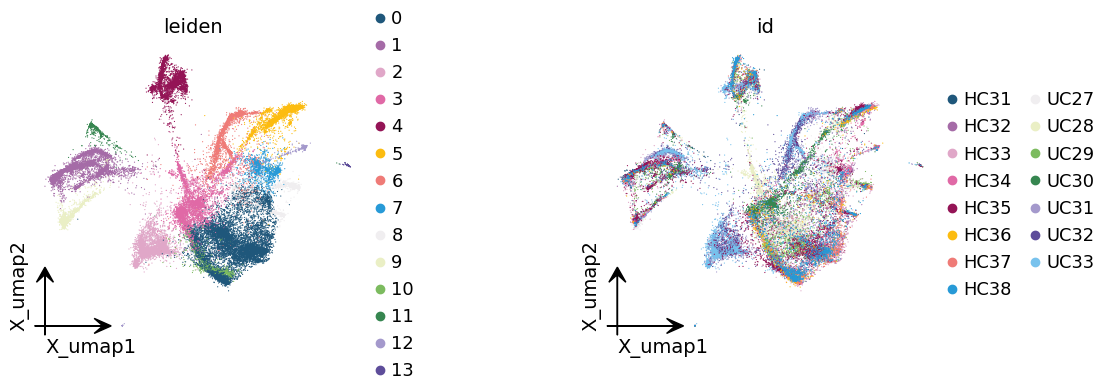

In [12]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

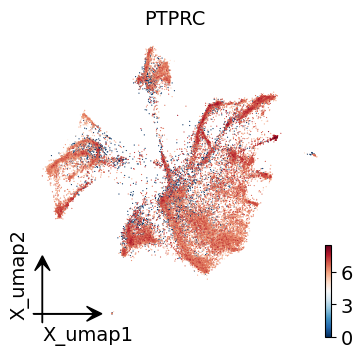

In [13]:
# 粗略查看免疫基因
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC'],
                frameon='small')

## GPT自动注释

In [14]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:23)


{'0': ['RPL35',
  'IL7R',
  'TOMM7',
  'LTB',
  'RPL26',
  'CD3E',
  'RPS29',
  'LDHB',
  'RPL38',
  'CD3D'],
 '1': ['FTH1',
  'S100A8',
  'CST3',
  'NEAT1',
  'LYZ',
  'FTL',
  'GPX1',
  'FCN1',
  'TYROBP',
  'S100A9'],
 '10': ['TCF7',
  'LEF1',
  'NDFIP1',
  'CD8A',
  'CD8B',
  'LDHB',
  'RPL38',
  'LINC02446',
  'NOSIP',
  'NELL2'],
 '11': ['FCER1A',
  'CST3',
  'HLA.DRB1',
  'HLA.DQB1',
  'HLA.DPA1',
  'HLA.DRA',
  'HLA.DPB1',
  'HLA.DQA1',
  'HLA.DRB5',
  'CD74'],
 '12': ['NKTR',
  'DERL3',
  'MZB1',
  'JCHAIN',
  'MTRNR2L12',
  'OGT',
  'SYNE2',
  'IGHA1',
  'DDX17',
  'TXNDC5'],
 '13': ['C12orf75',
  'NPC2',
  'TCF4',
  'SEC61B',
  'JCHAIN',
  'IRF7',
  'CCDC50',
  'PLD4',
  'IRF8',
  'ITM2C'],
 '2': ['IL7R',
  'MAL',
  'LTB',
  'CD3E',
  'FLT3LG',
  'LEF1',
  'LDHB',
  'NOSIP',
  'NPM1',
  'IL32'],
 '3': ['RPS29'],
 '4': ['CD37',
  'HLA.DRB1',
  'HLA.DQB1',
  'MS4A1',
  'HLA.DPA1',
  'HLA.DRA',
  'CD79A',
  'HLA.DPB1',
  'HLA.DQA1',
  'CD74'],
 '5': ['GNLY',
  'SPON2',
  'CTSW'

In [15]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='PBMC',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'T cells',
 '1': 'Monocytes',
 '10': 'CD8+ T cells',
 '11': 'Dendritic cells',
 '12': 'Plasma cells',
 '13': 'cDC2 dendritic cells',
 '2': 'Naive T cells',
 '3': 'Unknown',
 '4': 'B cells',
 '5': 'NK cells',
 '6': 'NK cells',
 '7': 'NK cells',
 '8': 'NK cells',
 '9': 'Monocytes'}

In [ ]:
#os.environ['AGI_API_KEY'] = 'sk-p0VgGvztXDK2erOoUul7cHcSDt4UduGk6f8voA0zn1F1L5xe'
#result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='moonshot-v1-8k',
                               provider='kimi',
                               topgenenumber=10)
#result

In [16]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

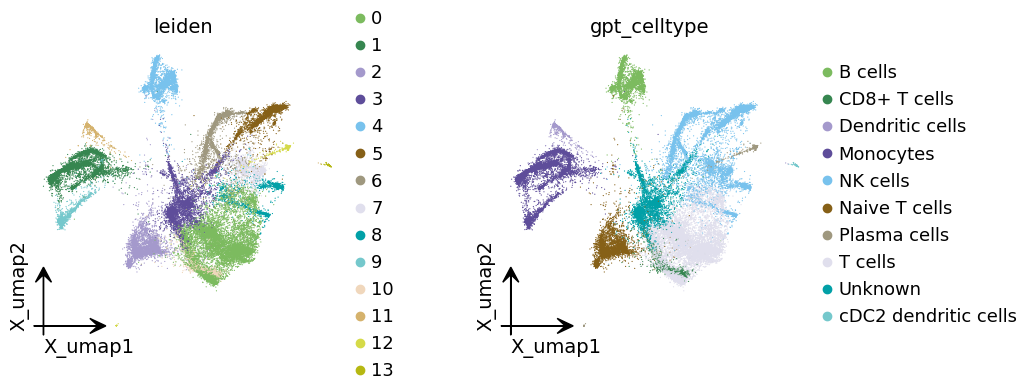

In [17]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [18]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
T cells                 24.263338
NK cells                23.330886
Monocytes               17.134116
Naive T cells           10.653451
Unknown                 10.408713
B cells                  9.713656
CD8+ T cells             1.926089
Dendritic cells          1.160059
Plasma cells             0.859031
cDC2 dendritic cells     0.550661
Name: proportion, dtype: float64
